# Petrophysical Evaluation & Well Log Visualization

This notebook integrates the custom `petrophysics.py` calculation engine with `matplotlib` well log visualization. 

It computes key petrophysical properties from raw well log data (`WellData.csv`):
- **Shale Volume ($V_{sh}$)**: Linear Index and Steiber non-linear model
- **Density Porosity ($\\phi_d$ / PHID)**: Derived from bulk density ($\\rho_b$)
- **Sonic Porosity ($\\phi_s$ / PHIS)**: Derived from sonic transit time ($\\Delta t$) via Wyllie time-average
- **Neutron-Density Combination Porosity ($\\phi_{nd}$ / PHIND)**: Root-Mean-Square (RMS) method
- **Effective Porosity ($\\phi_e$ / PHIE)**: Total porosity corrected for shale volume fraction


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import petrophysics as petro

# Load well log data
df = pd.read_csv("WellData.csv", header=0)
df = df.rename(columns=str.strip)  # Clean column names
df = df.replace(-999, np.nan)      # Replace null values (-999) with NaN

print("Loaded Well Data:")
print(f"- Total depth records: {len(df)}")
print(f"- Depth range: {df['DEPTH'].min():.2f} ft to {df['DEPTH'].max():.2f} ft")
print(f"- Available log curves: {df.columns.tolist()}")


Loaded Well Data:
- Total depth records: 1921
- Depth range: 4609.80 ft to 4801.80 ft
- Available log curves: ['DEPTH', 'GR', 'DT', 'RHOB', 'DRHO', 'NPHI']


## 1. Petrophysical Calculations using `petrophysics.py`  
We compute sand ($GR_{sand}$) and shale ($GR_{shale}$) baselines using 5th and 95th percentiles of the Gamma Ray curve, then invoke `compute_all_petrophysical_properties()` from `petrophysics.py`.

In [2]:
# Compute sand and shale baseline values (5th and 95th percentiles)
GR_sand = round(np.percentile(df['GR'].dropna(), 5), 2)
GR_shale = round(np.percentile(df['GR'].dropna(), 95), 2)

print(f"Gamma Ray Baselines -> GR_sand (5th %): {GR_sand} API | GR_shale (95th %): {GR_shale} API\n")

# Run full petrophysical calculation suite
df_petro = petro.compute_all_petrophysical_properties(
    df,
    gr_sand=GR_sand,
    gr_shale=GR_shale,
    rho_ma=2.65,
    rho_f=1.0,
    dt_ma=55.5
)

# Display statistical summary of computed petrophysical properties
summary = df_petro[['GR', 'RHOB', 'NPHI', 'DT', 'VSH_linear', 'VSH_steiber', 'PHID', 'PHIS', 'PHIND', 'PHIE']].describe().T
print(summary[['count', 'mean', 'std', 'min', '50%', 'max']])


Gamma Ray Baselines -> GR_sand (5th %): 25.59 API | GR_shale (95th %): 117.15 API

              count       mean        std        min        50%         max
GR           1921.0  67.543849  31.455753  19.605911  63.487732  137.462921
RHOB         1921.0   2.554064   0.121438   1.947107   2.557842    2.788836
NPHI         1921.0   0.114056   0.039322   0.033476   0.111190    0.417384
DT           1918.0  67.398183   4.525434  54.929482  67.392708   89.620895
VSH_linear   1921.0   0.456472   0.335756   0.000000   0.413911    1.000000
VSH_steiber  1921.0   0.315791   0.314215   0.000000   0.190551    1.000000
PHID         1921.0   0.064326   0.066574   0.000000   0.055853    0.425996
PHIS         1918.0   0.089128   0.033890   0.000000   0.089084    0.255587
PHIND        1921.0   0.098158   0.043895   0.023671   0.092680    0.371505
PHIE         1921.0   0.056297   0.050599   0.000000   0.050733    0.303503


## 2. Multi-Track Petrophysical Well Log Display

Visualization of raw logs alongside calculated petrophysical properties across 4 composite tracks:
- **Track 1**: Gamma Ray Log (GR) with Clean Sand & Shale baselines
- **Track 2**: Shale Volume ($V_{sh}$) - Linear vs. Steiber models with shading
- **Track 3**: Porosity Logs ($\\phi_d$ Density, $\\phi_s$ Sonic, $\\phi_n$ Neutron)
- **Track 4**: Total Combination Porosity ($\\phi_{nd}$) vs. Effective Porosity ($\\phi_e$) with Clay-bound Water shading


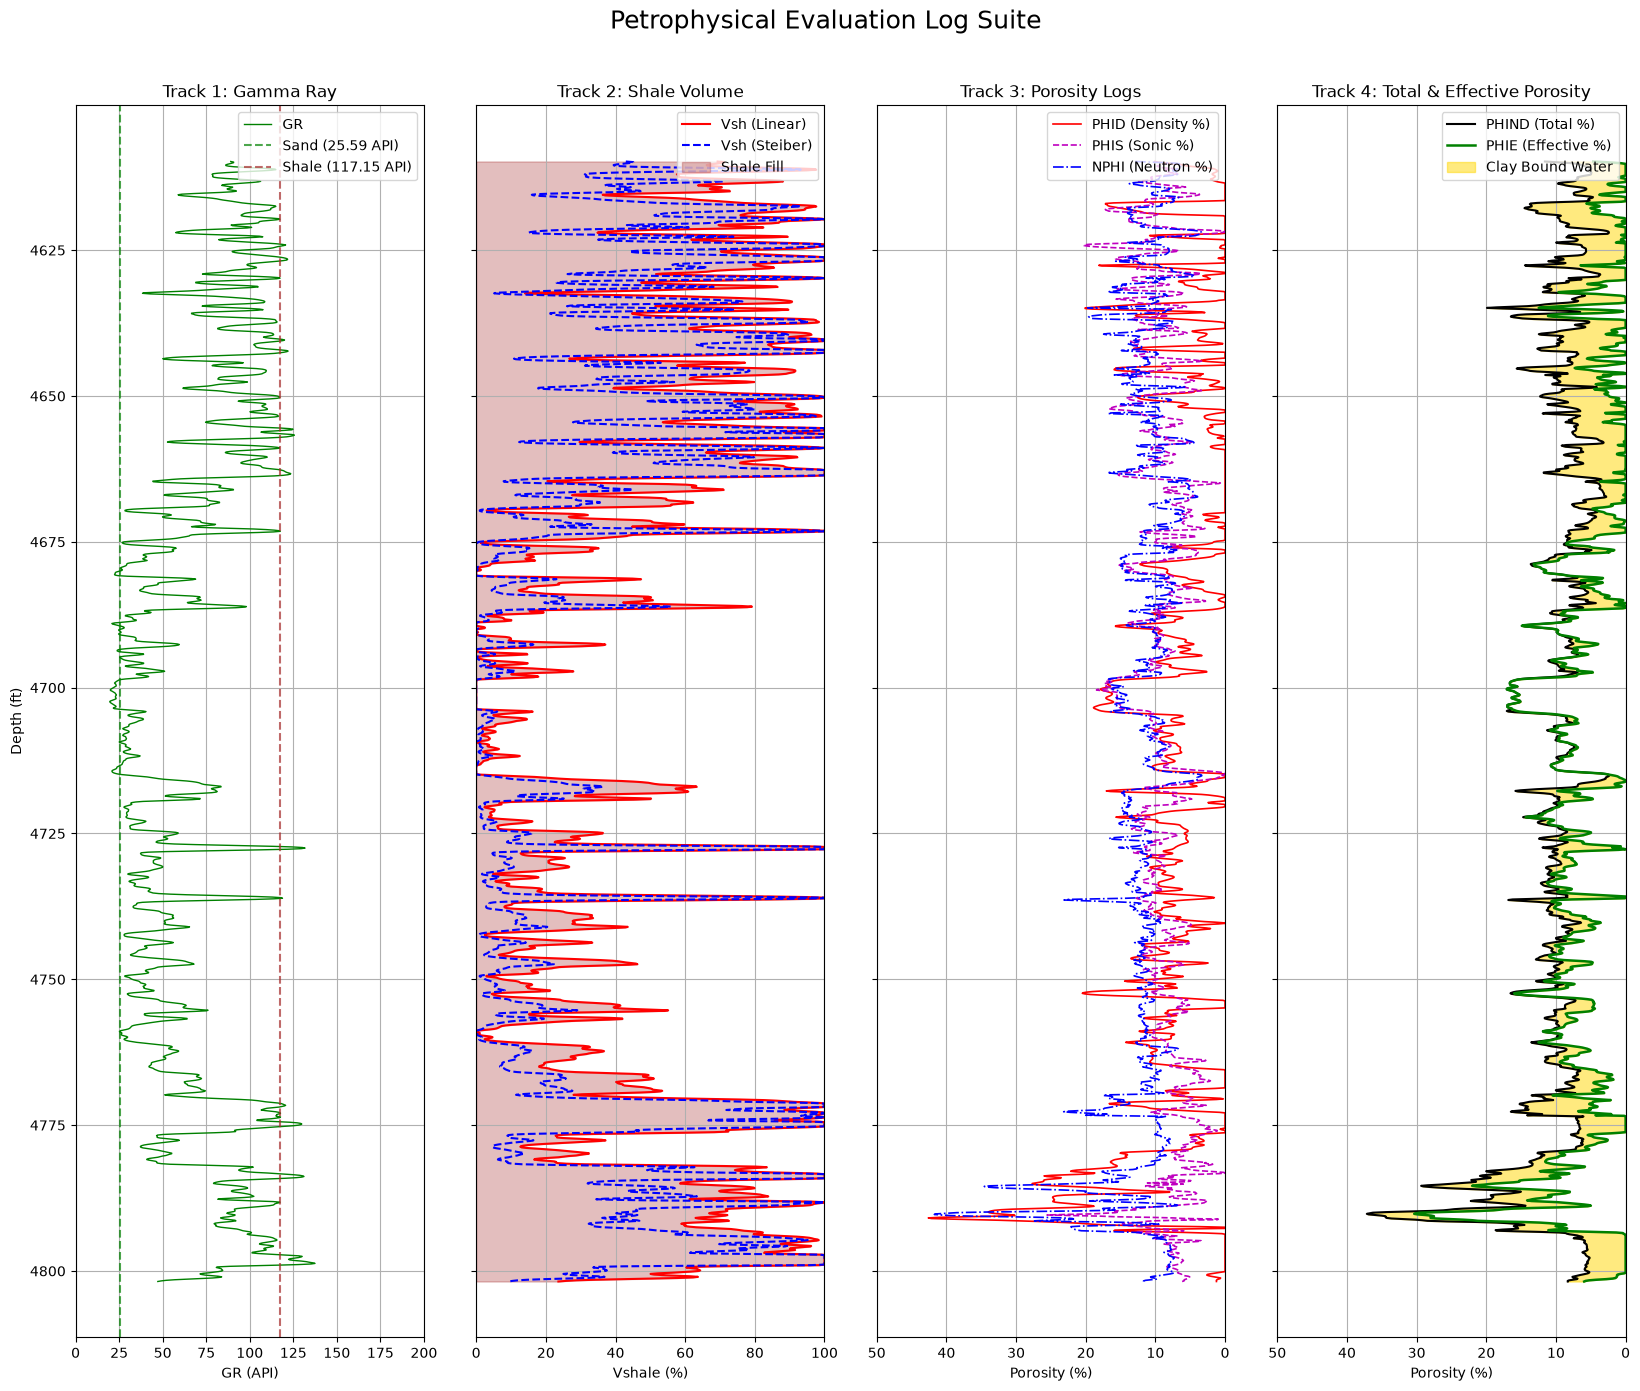

In [3]:
# Create multi-track petrophysical visualization plot
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 16), sharey=True)
plt.subplots_adjust(wspace=0.15)

# --- Track 1: Gamma Ray ---
ax1.plot(df_petro['GR'], df_petro['DEPTH'], 'g-', label='GR', linewidth=1)
ax1.axvline(GR_sand, color='green', linestyle='--', alpha=0.7, label=f'Sand ({GR_sand} API)')
ax1.axvline(GR_shale, color='brown', linestyle='--', alpha=0.7, label=f'Shale ({GR_shale} API)')
ax1.set_xlabel('GR (API)')
ax1.set_xlim(0, 200)
ax1.set_ylabel('Depth (ft)')
ax1.set_title('Track 1: Gamma Ray')
ax1.grid(True)
ax1.invert_yaxis()
ax1.legend(loc='upper right')

# --- Track 2: Shale Volume (Vshale) ---
ax2.plot(df_petro['VSH_linear'] * 100, df_petro['DEPTH'], 'r-', label='Vsh (Linear)', linewidth=1.5)
ax2.plot(df_petro['VSH_steiber'] * 100, df_petro['DEPTH'], 'b--', label='Vsh (Steiber)', linewidth=1.5)
ax2.fill_betweenx(df_petro['DEPTH'], 0, df_petro['VSH_linear'] * 100, color='brown', alpha=0.3, label='Shale Fill')
ax2.set_xlabel('Vshale (%)')
ax2.set_xlim(0, 100)
ax2.set_title('Track 2: Shale Volume')
ax2.grid(True)
ax2.legend(loc='upper right')

# --- Track 3: Porosity Logs (PHID, PHIS, NPHI) ---
ax3.plot(df_petro['PHID'] * 100, df_petro['DEPTH'], 'r-', label='PHID (Density %)', linewidth=1.2)
ax3.plot(df_petro['PHIS'] * 100, df_petro['DEPTH'], 'm--', label='PHIS (Sonic %)', linewidth=1.2)
ax3.plot(df_petro['NPHI'] * 100, df_petro['DEPTH'], 'b-.', label='NPHI (Neutron %)', linewidth=1.2)
ax3.set_xlabel('Porosity (%)')
ax3.set_xlim(50, 0)  # Standard reverse scale for porosity
ax3.set_title('Track 3: Porosity Logs')
ax3.grid(True)
ax3.legend(loc='upper right')

# --- Track 4: Combination & Effective Porosity ---
ax4.plot(df_petro['PHIND'] * 100, df_petro['DEPTH'], 'k-', label='PHIND (Total %)', linewidth=1.5)
ax4.plot(df_petro['PHIE'] * 100, df_petro['DEPTH'], 'g-', label='PHIE (Effective %)', linewidth=1.8)
ax4.fill_betweenx(df_petro['DEPTH'], df_petro['PHIE'] * 100, df_petro['PHIND'] * 100, color='gold', alpha=0.5, label='Clay Bound Water')
ax4.set_xlabel('Porosity (%)')
ax4.set_xlim(50, 0)
ax4.set_title('Track 4: Total & Effective Porosity')
ax4.grid(True)
ax4.legend(loc='upper right')

plt.suptitle('Petrophysical Evaluation Log Suite', fontsize=18, y=0.94)
plt.show()


## 3. Depth-Specific Petrophysical Inspector

Evaluate all raw logs and computed petrophysical parameters at a targeted reservoir depth.

In [4]:
# Query petrophysical results at a target depth (e.g. 5000 ft or nearest available)
target_depth = 5000.0
idx = (df_petro['DEPTH'] - target_depth).abs().idxmin()
row = df_petro.loc[idx]

print(f"=== Petrophysical Analysis at Depth: {row['DEPTH']:.2f} ft ===") 
print(f"Raw Logs:")
print(f"  • Gamma Ray (GR)            : {row['GR']:.2f} API")
print(f"  • Bulk Density (RHOB)       : {row['RHOB']:.3f} g/cc")
print(f"  • Neutron Porosity (NPHI)   : {row['NPHI']:.3f} (fraction)")
print(f"  • Sonic Transit Time (DT)   : {row['DT']:.2f} us/ft")
print("-" * 55)
print(f"Computed Petrophysical Properties (from petrophysics.py):")
print(f"  • Vshale (Linear Model)     : {row['VSH_linear']*100:.2f} %")
print(f"  • Vshale (Steiber Model)    : {row['VSH_steiber']*100:.2f} %")
print(f"  • Density Porosity (PHID)   : {row['PHID']*100:.2f} %")
print(f"  • Sonic Porosity (PHIS)     : {row['PHIS']*100:.2f} %")
print(f"  • Total Porosity (PHIND)    : {row['PHIND']*100:.2f} %")
print(f"  • Effective Porosity (PHIE) : {row['PHIE']*100:.2f} %")


=== Petrophysical Analysis at Depth: 4801.80 ft ===
Raw Logs:
  • Gamma Ray (GR)            : 47.20 API
  • Bulk Density (RHOB)       : 2.630 g/cc
  • Neutron Porosity (NPHI)   : 0.117 (fraction)
  • Sonic Transit Time (DT)   : 63.74 us/ft
-------------------------------------------------------
Computed Petrophysical Properties (from petrophysics.py):
  • Vshale (Linear Model)     : 23.60 %
  • Vshale (Steiber Model)    : 9.34 %
  • Density Porosity (PHID)   : 1.24 %
  • Sonic Porosity (PHIS)     : 6.17 %
  • Total Porosity (PHIND)    : 8.31 %
  • Effective Porosity (PHIE) : 5.95 %
